# Projection System — Gaussian at Different Magnifications

This notebook:
1. Solves the IL1/IL2/IL3 system and builds a projection `LensSystem`.
2. Propagates a single Gaussian beam through the projection column at several Mode C magnification steps.
3. Shows both a ray-diagram view (`plot_model`) and the evaluated intensity at the image plane for each magnification.

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from temgym_core.components import Lens, Plane, Detector
from temgym_core.gaussian import make_gaussian
from temgym_core.source import make_waist_divergence_rays
from temgym_core.ray import Ray
from temgym_core.run import run_to_end
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.plotting import plot_model, legacy_beam_plot_params
from temgym_core.constants import energy2wavelength
from temgym_core import ScaleYX, ShapeYX

from temgym_core.tem_model import (
    solve_il_system,
    build_projection_system,
    LensSystem,
)

print("Imports OK")

Imports OK


## 1. Solve IL system and build the projection LensSystem

This runs `differential_evolution` + `L-BFGS-B` to fit `Gc` and `α` for IL1–IL3, then wraps the result into a `LensSystem` with a magnification dial curve for Mode C (30k–600k×).

In [2]:
print("Solving IL system …")
il = solve_il_system(M_obj=60.0, M_proj=100.0, mode_filter="C", de_seed=42)
print(f"  Success: {il['success']}, Loss: {il['loss']:.4e}")
for i, name in enumerate(("IL1", "IL2", "IL3")):
    print(f"  {name}: Gc={il['gc'][i]:.3f}, α={il['alpha_nl'][i]:.3f}")

# Build the projection LensSystem (OPL_post → IL1 → IL2 → IL3 → PL1 → screen)
proj = build_projection_system(
    il,
    d_sample_to_opl_post=2.083e-3,
    f_opl_post=5.0e-3,
    f_pl1=3.25e-3,
    sample_z=0.0,
)

mag_curve = proj.dial_curves["magnification"]
print(f"\nProjection lenses: {proj.geometry.lens_names}")
print(f"Mode C magnifications: {mag_curve.control_values.astype(int)}")

Solving IL system …
  Success: True, Loss: 2.5905e+02
  IL1: Gc=560.314, α=-512.330
  IL2: Gc=456.744, α=-283.557
  IL3: Gc=166.789, α=-179.799

Projection lenses: ('OPL_post', 'IL1', 'IL2', 'IL3', 'PL1')
Mode C magnifications: [ 30000  40000  50000  60000  80000 100000 120000 150000 200000 250000
 300000 400000 500000 600000]


## 2. Choose magnifications to compare

We pick a selection of Mode C steps to show how the Gaussian beam changes across the magnification range.

In [3]:
# Pick a subset of Mode C magnifications for the comparison
selected_mags = [30_000, 60_000, 100_000, 200_000, 400_000, 600_000]

# Beam parameters
voltage = 200e3  # V
waist_m = 1e-9   # 1 nm waist at sample plane (object for the projection system)

print(f"Voltage:  {voltage/1e3:.0f} kV")
print(f"Waist:    {waist_m*1e9:.1f} nm")
print(f"Selected: {selected_mags}")

Voltage:  200 kV
Waist:    1.0 nm
Selected: [30000, 60000, 100000, 200000, 400000, 600000]


## 3. Ray diagrams — `plot_model` at each magnification

Build the projection column components and plot waist/divergence rays through the system for each selected magnification.

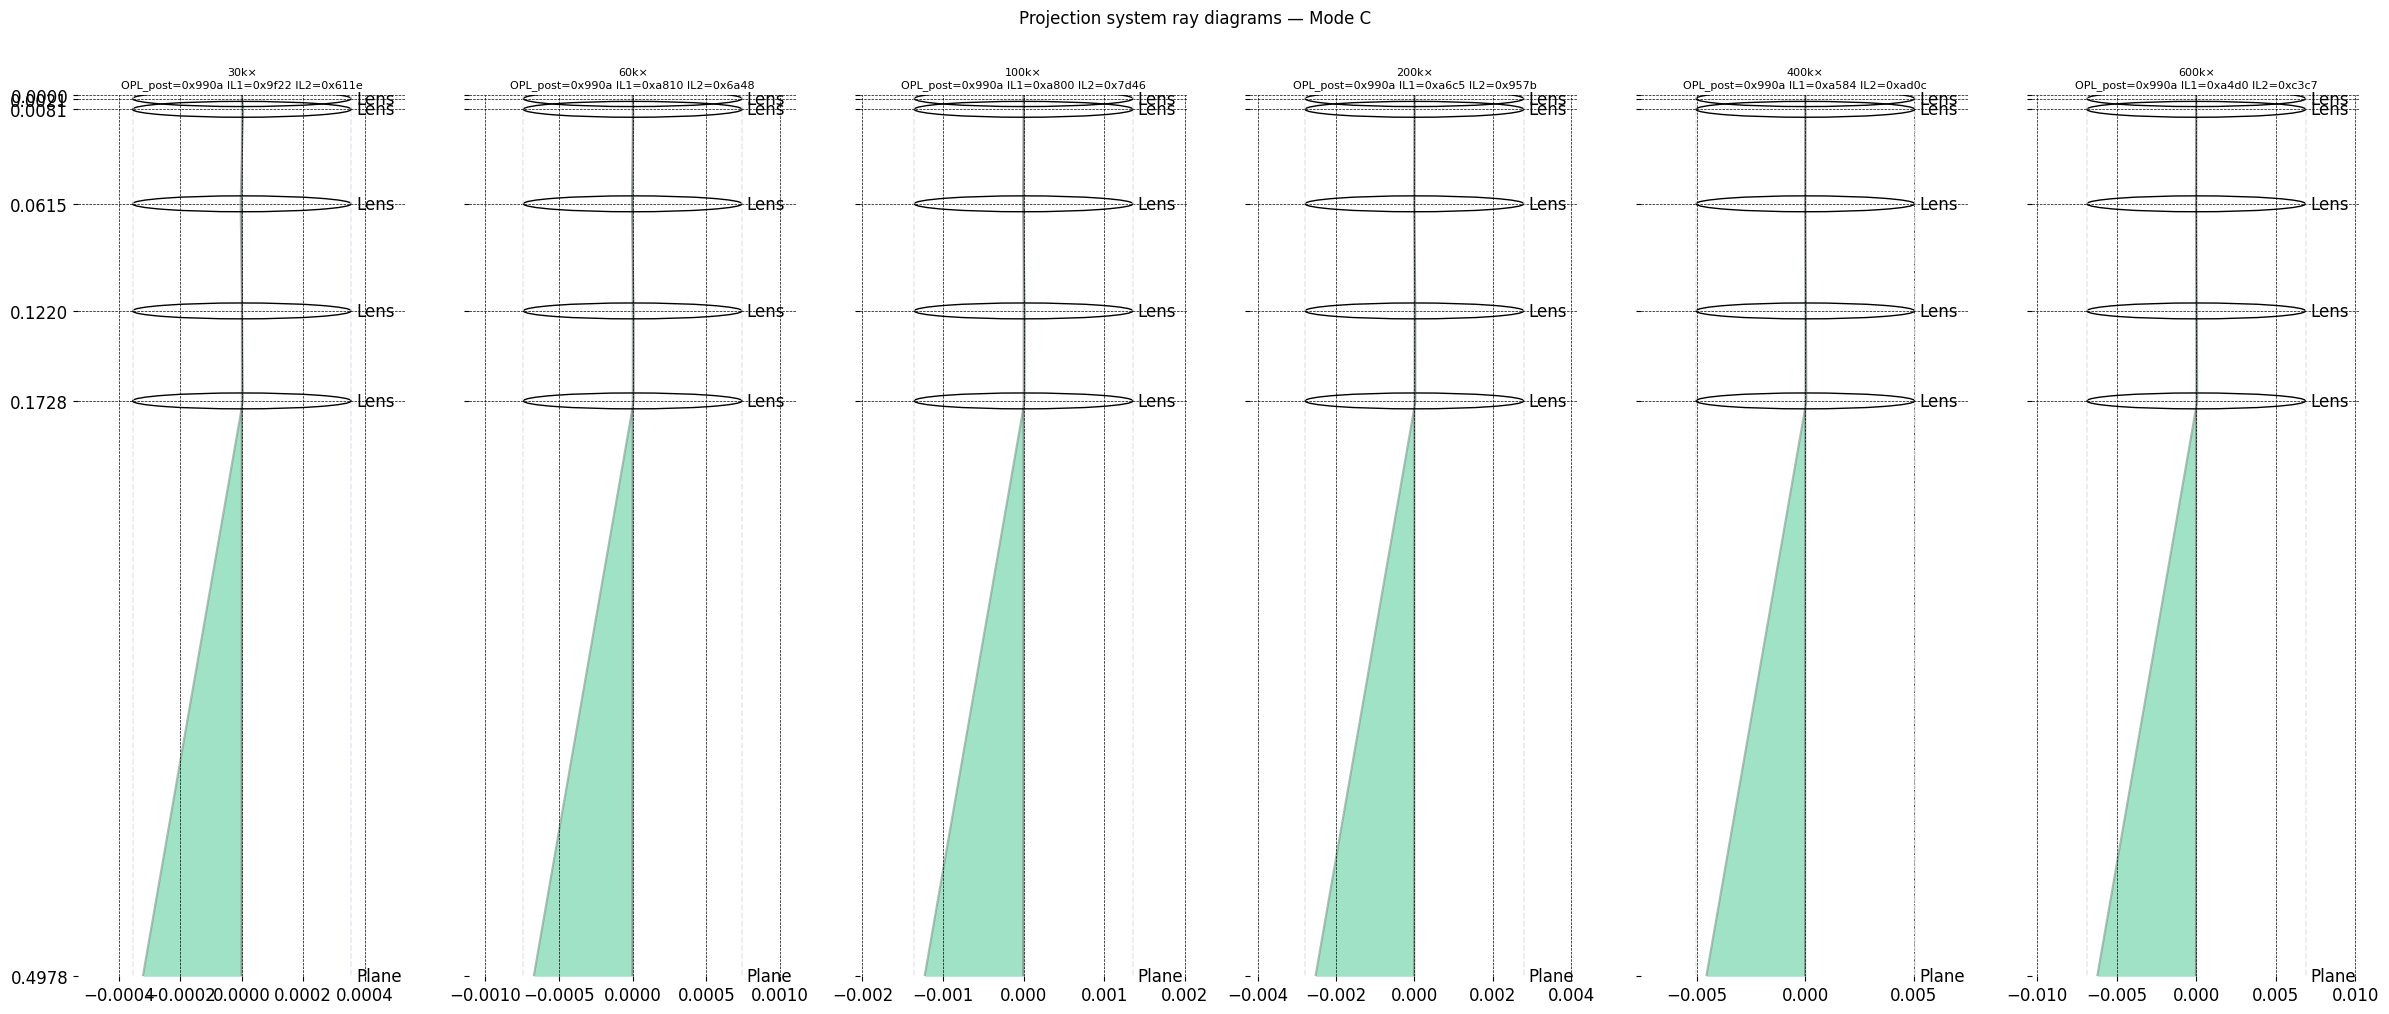

In [4]:
n = len(selected_mags)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 10), sharey=True)

for idx, mag in enumerate(selected_mags):
    ax = axes[idx]

    # Build components for this magnification
    comps = proj.build_components(
        "magnification", float(mag), z0=0.0, end_plane=True,
    )

    # Two-ray waist/divergence basis
    rays = make_waist_divergence_rays(
        waist=waist_m, voltage=voltage, z=0.0,
    )

    plot_model(
        comps, rays=rays, ax=ax,
        plot_params=legacy_beam_plot_params(),
    )

    # DAC hex for the title
    state = proj.realize("magnification", float(mag))
    hex_strs = [f"{k}={v}" for k, v in state["dac_hex"].items()]
    ax.set_title(f"{mag // 1000}k×\n" + " ".join(hex_strs[:3]), fontsize=8)

fig.suptitle("Projection system ray diagrams — Mode C", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 4. Gaussian beam propagation — intensity at the image plane

For each magnification, propagate a single Gaussian beam through the lens stack using `run_to_end`, then evaluate the field on a detector at the screen plane. The image-plane spot size should scale with magnification.

In [9]:
# Detector parameters — we use a common pixel grid and adapt extent per mag
det_shape = ShapeYX(512, 512)

results = {}
for mag in selected_mags:
    # Build components with a Detector as the final element
    comps_list = list(proj.build_components(
        "magnification", float(mag), z0=0.0, end_plane=False,
    ))

    # Estimate the image-plane spot size to set sensible detector pixel size
    # Object waist × magnification (rough estimate from IL mag portion)
    M_il = mag / (60.0 * 100.0)  # IL magnification fraction
    expected_spot = waist_m * mag  # full-column magnification
    pixel_m = 50e-6

    # z-position of the screen (last element z)
    z_screen = proj.geometry.z_positions(0.0)["_end"]

    det = Detector(
        z=z_screen,
        pixel_size=ScaleYX(pixel_m, pixel_m),
        shape=det_shape,
    )
    comps_with_det = tuple(comps_list) + (det,)

    # Create a single Gaussian beam at the sample plane
    beam_in = make_gaussian(
        x=0.0, y=0.0, dx=0.0, dy=0.0, z=0.0,
        voltage=voltage,
        waist_x=waist_m,
        waist_y=waist_m,
    )

    # Propagate
    beam_out = run_to_end(beam_in, comps_with_det)

    # Evaluate the field on the detector grid
    field = evaluate_gaussians_for(beam_out, det)
    intensity = np.abs(np.asarray(field)) ** 2

    results[mag] = {
        "intensity": intensity,
        "pixel_m": pixel_m,
        "beam_out": beam_out,
        "det": det,
    }
    print(f"  {mag:>7,}×  pixel={pixel_m*1e6:.3f} µm  peak_I={intensity.max():.4e}")

print("Done.")

   30,000×  pixel=50.000 µm  peak_I=9.3719e-12
   60,000×  pixel=50.000 µm  peak_I=2.2002e-12
  100,000×  pixel=50.000 µm  peak_I=6.6144e-13
  200,000×  pixel=50.000 µm  peak_I=1.5619e-13
  400,000×  pixel=50.000 µm  peak_I=4.8098e-14
  600,000×  pixel=50.000 µm  peak_I=2.5840e-14
Done.


## 5. Intensity images — side by side

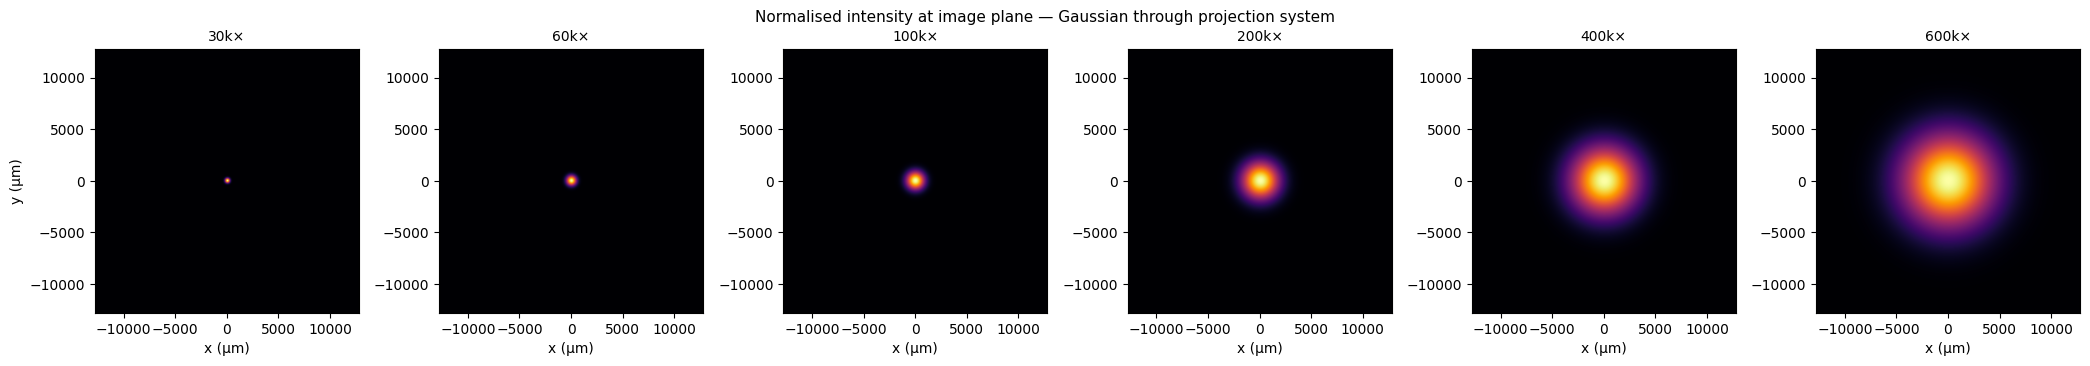

In [10]:
fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.5))

for idx, mag in enumerate(selected_mags):
    ax = axes[idx]
    r = results[mag]
    intensity = r["intensity"]
    px = r["pixel_m"]

    # Extent in µm
    half_x = det_shape.x * px * 1e6 / 2
    half_y = det_shape.y * px * 1e6 / 2
    extent = [-half_x, half_x, -half_y, half_y]

    im = ax.imshow(
        intensity / intensity.max(),
        extent=extent,
        origin="lower",
        cmap="inferno",
        vmin=0, vmax=1,
    )
    ax.set_title(f"{mag // 1000}k×", fontsize=10)
    ax.set_xlabel("x (µm)")
    if idx == 0:
        ax.set_ylabel("y (µm)")

fig.suptitle("Normalised intensity at image plane — Gaussian through projection system", fontsize=11)
fig.tight_layout()
plt.show()

## 6. Cross-section and spot-size summary

Plot a central line profile for each magnification and print the image-plane spot size (FWHM).

       Mag   Spot FWHM (µm)   Expected (µm)
---------------------------------------------
    30,000          350.000          70.650
    60,000          750.000         141.300
   100,000         1350.000         235.500
   200,000         2950.000         471.000
   400,000         5350.000         942.000
   600,000         7250.000        1413.000


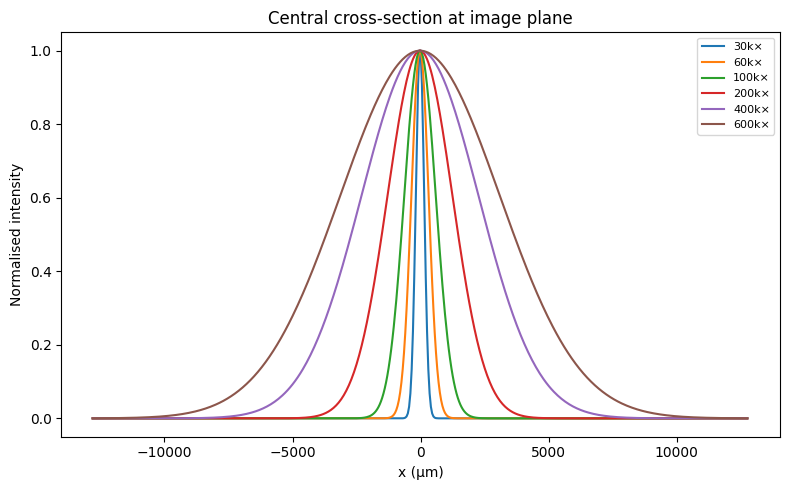

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

print(f"{'Mag':>10s}  {'Spot FWHM (µm)':>15s}  {'Expected (µm)':>14s}")
print("-" * 45)

for mag in selected_mags:
    r = results[mag]
    intensity = r["intensity"]
    px = r["pixel_m"]

    # Central horizontal cross-section
    mid = det_shape.y // 2
    profile = intensity[mid, :]
    profile_norm = profile / profile.max() if profile.max() > 0 else profile

    # x-axis in µm
    x_um = (np.arange(det_shape.x) - det_shape.x / 2) * px * 1e6

    ax.plot(x_um, profile_norm, label=f"{mag // 1000}k×")

    # Measure FWHM
    above_half = np.where(profile_norm >= 0.5)[0]
    if len(above_half) > 1:
        fwhm_px = above_half[-1] - above_half[0]
        fwhm_um = fwhm_px * px * 1e6
    else:
        fwhm_um = 0.0

    expected_um = waist_m * mag * 2.355 * 1e6  # Gaussian FWHM ≈ 2.355 σ
    print(f"{mag:>10,}  {fwhm_um:>15.3f}  {expected_um:>14.3f}")

ax.set_xlabel("x (µm)")
ax.set_ylabel("Normalised intensity")
ax.set_title("Central cross-section at image plane")
ax.legend(fontsize=8)
ax.set_xlim(-ax.get_xlim()[1], ax.get_xlim()[1])
fig.tight_layout()
plt.show()

## 7. DAC hex display — like the JEOL console

Print the DAC hex codes for each magnification step, mirroring what the microscope console would show.

In [12]:
header = f"{'Mag':>10s}"
for name in proj.geometry.lens_names:
    header += f"  {name:>10s}"
print(header)
print("-" * len(header))

for mag in selected_mags:
    state = proj.realize("magnification", float(mag))
    row = f"{mag:>10,}"
    for name in proj.geometry.lens_names:
        row += f"  {state['dac_hex'][name]:>10s}"
    print(row)

       Mag    OPL_post         IL1         IL2         IL3         PL1
----------------------------------------------------------------------
    30,000      0x990a      0x9f22      0x611e      0x9b35      0xfa00
    60,000      0x990a      0xa810      0x6a48      0x7f59      0xfa00
   100,000      0x990a      0xa800      0x7d46      0x7205      0xfa00
   200,000      0x990a      0xa6c5      0x957b      0x5c4a      0xfa00
   400,000      0x990a      0xa584      0xad0c      0x3e16      0xfa00
   600,000      0x990a      0xa4d0      0xc3c7      0x2771      0xfa00
